# Customer satisfaction of Icecream Flavours


In [1]:
import numpy as np  # useful for many scientific computing in Python
import pandas as pd # primary data structure library
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df= pd.read_csv('https://raw.githubusercontent.com/tec03/Datasets/main/datasets/satis.csv')
mpl.style.use('ggplot')  # optional: for ggplot-like style

In [3]:
mpl.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [4]:
df.head(2)

,Age,Gender,Ocupation,Monthly income,Price,Quality,Quantity,Availability,Taste,Flavours,...,Overal satisfaction,Consistency,Factor,Frowned,reason,Popular,My favorite,Kind,Preference,Recommend
0,33.0,Male,Research,">40, 000",5.0,5.0,5.0,4.0,4.0,5.0,...,4.0,4.0,Taste,No,NaN,Combo_VLM,Chocolate,More than one flavoured,agree,agree
1,39.0,Male,student,"<10,000",3.0,5.0,3.0,4.0,5.0,5.0,...,4.0,4.0,Taste,No,Quantity issues,Combo_VCS,Chocolate,More than one flavoured,neutral,neutral


Let's check how many missing values are there in each column:

In [5]:
df.isnull().sum()

,0
Age,5
Gender,5
Ocupation,5
Monthly income,5
Price,5
Quality,5
Quantity,5
Availability,5
Taste,5
Flavours,5


Let's check how many missing values are there in each Row:

In [6]:
df.isna().sum(1)

,0
0,1
1,0
2,1
3,1
4,1
5,0
6,0
7,1
8,0
9,1


- We see that there are at least 5 data is missing in each column.

Let us drop the columns and rows, if the entire data is missing:

In [7]:
df.dropna(axis = 1, how = 'all', inplace = True)
df.dropna(how = 'all', inplace = True)

In [8]:
df.isnull().sum()

,0
Age,0
Gender,0
Ocupation,0
Monthly income,0
Price,0
Quality,0
Quantity,0
Availability,0
Taste,0
Flavours,0


Let us drop the column `reason`, since 18 out of 50 data is missing:

In [9]:
df.drop('reason',
        axis = 1,
        inplace = True)
df.head(2)

,Age,Gender,Ocupation,Monthly income,Price,Quality,Quantity,Availability,Taste,Flavours,...,Size,Overal satisfaction,Consistency,Factor,Frowned,Popular,My favorite,Kind,Preference,Recommend
0,33.0,Male,Research,">40, 000",5.0,5.0,5.0,4.0,4.0,5.0,...,4.0,4.0,4.0,Taste,No,Combo_VLM,Chocolate,More than one flavoured,agree,agree
1,39.0,Male,student,"<10,000",3.0,5.0,3.0,4.0,5.0,5.0,...,2.0,4.0,4.0,Taste,No,Combo_VCS,Chocolate,More than one flavoured,neutral,neutral


We can convert `Age` to an `int` type :

In [10]:
df['Age'] = df['Age'].astype(int)
df.head(2)

,Age,Gender,Ocupation,Monthly income,Price,Quality,Quantity,Availability,Taste,Flavours,...,Size,Overal satisfaction,Consistency,Factor,Frowned,Popular,My favorite,Kind,Preference,Recommend
0,33,Male,Research,">40, 000",5.0,5.0,5.0,4.0,4.0,5.0,...,4.0,4.0,4.0,Taste,No,Combo_VLM,Chocolate,More than one flavoured,agree,agree
1,39,Male,student,"<10,000",3.0,5.0,3.0,4.0,5.0,5.0,...,2.0,4.0,4.0,Taste,No,Combo_VCS,Chocolate,More than one flavoured,neutral,neutral


In [11]:
def custom_cls(x):
    if (0<= x <= 20):
        return '<=20'
    elif (21<= x <= 30):
        return '21 - 30'
    elif (31<= x <= 40):
        return '31 - 40'
    else:
        return '>=40'

df['AgeGP'] = df.apply(lambda eje: custom_cls(eje['Age']),
                       axis=1)
df.head(2)

,Age,Gender,Ocupation,Monthly income,Price,Quality,Quantity,Availability,Taste,Flavours,...,Overal satisfaction,Consistency,Factor,Frowned,Popular,My favorite,Kind,Preference,Recommend,AgeGP
0,33,Male,Research,">40, 000",5.0,5.0,5.0,4.0,4.0,5.0,...,4.0,4.0,Taste,No,Combo_VLM,Chocolate,More than one flavoured,agree,agree,31 - 40
1,39,Male,student,"<10,000",3.0,5.0,3.0,4.0,5.0,5.0,...,4.0,4.0,Taste,No,Combo_VCS,Chocolate,More than one flavoured,neutral,neutral,31 - 40


```python
df.apply(lambda eje: custom_cls(eje['Age']), axis=1)
```


1. **`apply`**: This method is used to apply a function along a specified axis of the DataFrame. By default, `apply` works along columns (`axis=0`), but you can specify `axis=1` to apply the function along rows.

2. **`lambda eje: custom_cls(eje['Age'])`**: This is a lambda function that takes a row from the DataFrame and applies `custom_cls` to a specific part of that row.

   - **`eje`**: This is the argument of the lambda function and represents each row of the DataFrame when `axis=1` is used. You can think of `eje` as a Series object corresponding to a row of the DataFrame.
   - **`eje['Age']`**: This accesses the value in the 'Age' column of the current row (represented by `eje`).
   - **`custom_cls(eje['Age'])`**: This applies the function `custom_cls` to the value extracted from the 'Age' column.
    - `custom_cls` could be a function, a class constructor, or any callable object that processes the value of 'Age'.

3. **`axis=1`**: This tells `apply` to work row-wise. It means the lambda function will be applied to each row individually, not to each column.



Here’s an example to illustrate:

Suppose `df` looks like this:

| Name  | Age |
|-------|-----|
| Alice | 30  |
| Bob   | 25  |
| Carol | 35  |

If `custom_cls` is a function that squares the input value, then applying `df.apply(lambda eje: custom_cls(eje['Age']), axis=1)` would yield a Series with the squared ages:

| Result |
|--------|
| 900    |  (30^2)
| 625    |  (25^2)
| 1225   |  (35^2)

In [12]:
dFast = df.copy()

In [13]:
counts = df['AgeGP'].value_counts()
type(counts)

age_gp_counts = counts.to_frame()
age_gp_counts

,count
AgeGP,
21 - 30,30
<=20,11
31 - 40,7
>=40,2


Let's make a column of `%` for each age group. For, first we calculate the column sum.
- The column sum of `AgeGP` *cs_AgeGP* is :

In [14]:
age_gp_counts.rename(columns={'count': 'count_AgeGP'},
                     inplace=True
                     )

In [15]:
age_gp_counts.loc[:,'count_AgeGP']

,count_AgeGP
AgeGP,
21 - 30,30
<=20,11
31 - 40,7
>=40,2


In [16]:
cs_AgeGP  = age_gp_counts.loc[:,'count_AgeGP'].sum(axis=0)
cs_AgeGP

50

In [17]:
age_gp_counts['%'] = ((age_gp_counts.iloc[:,:]/cs_AgeGP)*100).round(2)
age_gp_counts

,count_AgeGP,%
AgeGP,,
21 - 30,30,60.0
<=20,11,22.0
31 - 40,7,14.0
>=40,2,4.0


Since this `counts` data frame is in decending order of `%` column, we reindex in ascending order of Age Group in index:

In [18]:
age_gp_counts

,count_AgeGP,%
AgeGP,,
21 - 30,30,60.0
<=20,11,22.0
31 - 40,7,14.0
>=40,2,4.0


In [19]:
age_gp_counts.index

Index(['21 - 30', '<=20', '31 - 40', '>=40'], dtype='object', name='AgeGP')

In [20]:
age_gp_counts = age_gp_counts.reindex(["<=20", "21 - 30", "31 - 40", ">=40"])
age_gp_counts

,count_AgeGP,%
AgeGP,,
<=20,11,22.0
21 - 30,30,60.0
31 - 40,7,14.0
>=40,2,4.0


To make the `index` as a colum, we may use `reset_index()` function, as:

In [21]:
age_gp_counts = age_gp_counts.reset_index()
age_gp_counts

,AgeGP,count_AgeGP,%
0,<=20,11,22.0
1,21 - 30,30,60.0
2,31 - 40,7,14.0
3,>=40,2,4.0


In [22]:
#age_gp_counts = age_gp_counts.rename({'index': 'Age_group'},
#                       axis=1
#                      )
#age_gp_counts

Now, we make a pie chart.

- Each slice represent the size of the corresponding value in the column
- Defalut label is index
    - we can specify any column as label

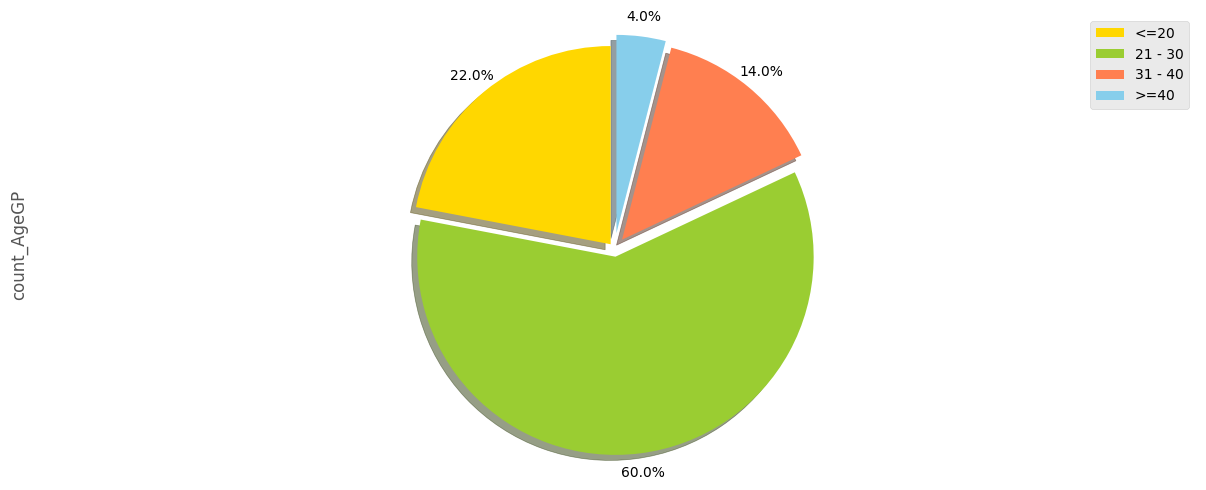

In [23]:
explode_list = [0.03, 0.04, 0.06, 0.08] # ratio for each continent with which to offset each wedge.
colors_list  = ['gold', 'yellowgreen', 'coral', 'skyblue', 'lightgreen', 'pink']

age_gp_counts['count_AgeGP'].plot(kind='pie',
                           figsize=(15, 6),
                           autopct='%1.1f%%',
                           startangle=90,
                           shadow=True,
                           labels=None,                  # turn off labels on pie chart
                           pctdistance=1.1,              # the ratio between the pie center and start of text label
                           explode=explode_list,         # 'explode' lowest 3 continents
                           colors=colors_list,
                         )

plt.axis('equal')
plt.legend(labels=age_gp_counts.AgeGP,
           bbox_to_anchor=(1.0,1.0));  # add legend

The same information in a barchart would be like:

In [24]:
age_gp_counts.head()

,AgeGP,count_AgeGP,%
0,<=20,11,22.0
1,21 - 30,30,60.0
2,31 - 40,7,14.0
3,>=40,2,4.0


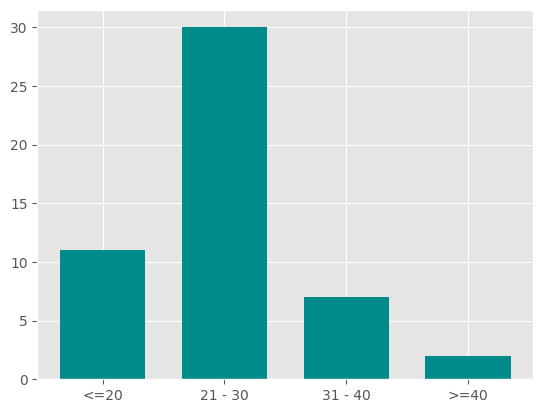

In [25]:
x = list(age_gp_counts['AgeGP'])
y = list(age_gp_counts['count_AgeGP'])
plt.bar(x, y, width=0.7, color= 'darkcyan');

Now the pie chart and the barchart, side by side for easy comparison:

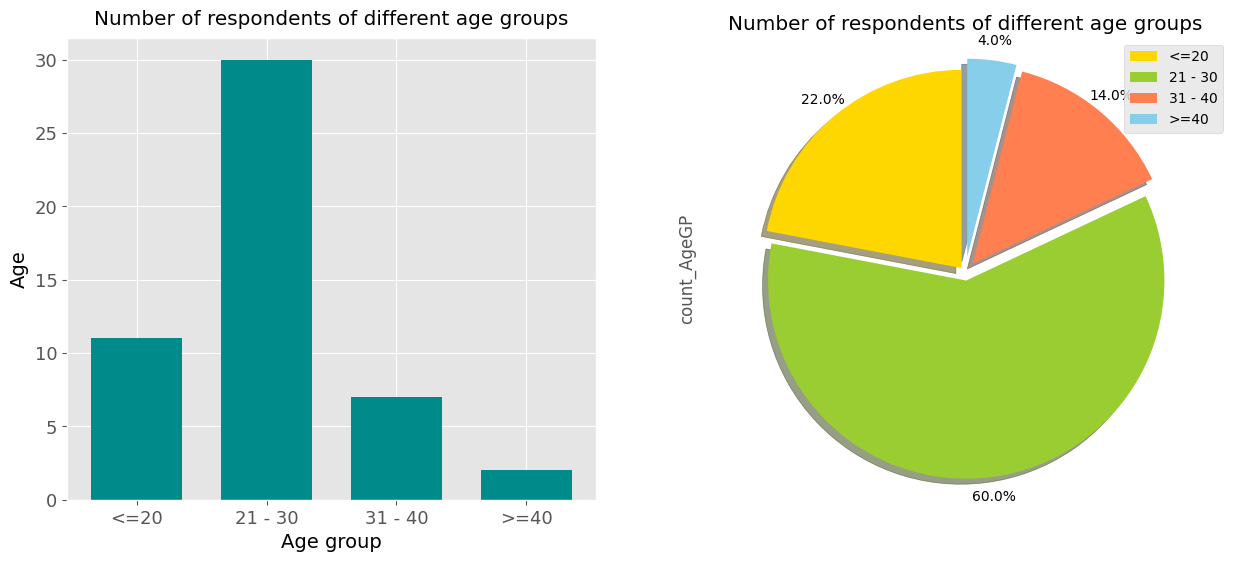

In [26]:
x = list(age_gp_counts['AgeGP'])
y = list(age_gp_counts['count_AgeGP'])
plt.rcParams["figure.figsize"] = (15,7)


plt.subplot(1,2,1)

plt.bar(x, y, width=0.7, color= 'darkcyan')   #the barchart

plt.xlabel('Age group', fontweight='regular', color = 'black', fontsize='14', horizontalalignment='center')
plt.ylabel('Age', fontweight='regular', color = 'black', fontsize='14', horizontalalignment='center')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.title('Number of respondents of different age groups', y = 1.01)


plt.subplot(1,2,2)


explode_list = [0.03, 0.04, 0.06, 0.08] # ratio for each continent with which to offset each wedge.
colors_list = ['gold', 'yellowgreen', 'coral', 'skyblue', 'lightgreen', 'pink']

age_gp_counts['count_AgeGP'].plot(kind='pie',
                           figsize=(15, 6),
                           autopct='%1.1f%%',
                           startangle=90,
                           shadow=True,
                           labels=None,                  # turn off labels on pie chart
                           pctdistance=1.1,              # the ratio between the pie center and start of text label
                           explode=explode_list,         # 'explode' lowest 3 continents
                           colors=colors_list,
                         )

plt.axis('equal')

plt.legend(labels=age_gp_counts.AgeGP,
           bbox_to_anchor=(1.0,1.0))  # add legend
plt.title('Number of respondents of different age groups', y=1)

plt.savefig('sample_data/age_group1.png')
plt.show()

Alternatively:

In [27]:
dFast

,Age,Gender,Ocupation,Monthly income,Price,Quality,Quantity,Availability,Taste,Flavours,...,Overal satisfaction,Consistency,Factor,Frowned,Popular,My favorite,Kind,Preference,Recommend,AgeGP
0,33,Male,Research,">40, 000",5.0,5.0,5.0,4.0,4.0,5.0,...,4.0,4.0,Taste,No,Combo_VLM,Chocolate,More than one flavoured,agree,agree,31 - 40
1,39,Male,student,"<10,000",3.0,5.0,3.0,4.0,5.0,5.0,...,4.0,4.0,Taste,No,Combo_VCS,Chocolate,More than one flavoured,neutral,neutral,31 - 40
2,40,Female,Teaching,">40, 000",3.0,4.0,4.0,4.0,3.0,4.0,...,4.0,4.0,Taste,No,Combo_VCS,Caramel,More than one flavoured,disagree,neutral,31 - 40
3,27,Male,Student,"<10,000",5.0,5.0,3.0,4.0,5.0,5.0,...,4.0,4.0,Taste,No,Combo_VCS,Strawbery,More than one flavoured,agree,agree,21 - 30
4,23,Female,Tutor,"10,000 - 20,000",5.0,5.0,4.0,4.0,5.0,5.0,...,5.0,5.0,Quality,No,Combo_VCS,Vanila,single flavoured,agree,Strongly agree,21 - 30
5,27,Female,Student,"<10,000",3.0,3.0,3.0,3.0,3.0,3.0,...,3.0,4.0,Taste,No,Combo_CRC,Chocolate,single flavoured,neutral,agree,21 - 30
6,48,Female,House wife,"<10,000",4.0,4.0,4.0,4.0,4.0,4.0,...,4.0,4.0,Taste,No,Combo_VCS,Vanila,single flavoured,neutral,agree,>=40
7,15,Female,Student,"<10,000",3.0,4.0,4.0,4.0,5.0,5.0,...,5.0,5.0,Taste,No,Combo_CRC,Caramel,More than one flavoured,agree,agree,<=20
8,28,Female,Student,"10,000 - 20,000",3.0,3.0,3.0,4.0,4.0,3.0,...,3.0,4.0,Quality,No,Combo_VCS,Chocolate,More than one flavoured,neutral,agree,21 - 30
9,24,Male,Engineer,"<10,000",3.0,5.0,4.0,5.0,5.0,5.0,...,4.0,5.0,Quality,No,Combo_VCS,Chocolate,single flavoured,agree,agree,21 - 30


In [28]:
df_grouped = dFast.groupby(['AgeGP']).count()
df_grouped

,Age,Gender,Ocupation,Monthly income,Price,Quality,Quantity,Availability,Taste,Flavours,...,Size,Overal satisfaction,Consistency,Factor,Frowned,Popular,My favorite,Kind,Preference,Recommend
AgeGP,,,,,,,,,,,,,,,,,,,,,
21 - 30,30,30,30,30,30,30,30,30,30,30,...,30,30,30,30,30,30,30,30,30,30
31 - 40,7,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7
<=20,11,11,11,11,11,11,11,11,11,11,...,11,11,11,11,11,11,11,11,11,11
>=40,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


In [29]:
df_grouped.index

Index(['21 - 30', '31 - 40', '<=20', '>=40'], dtype='object', name='AgeGP')

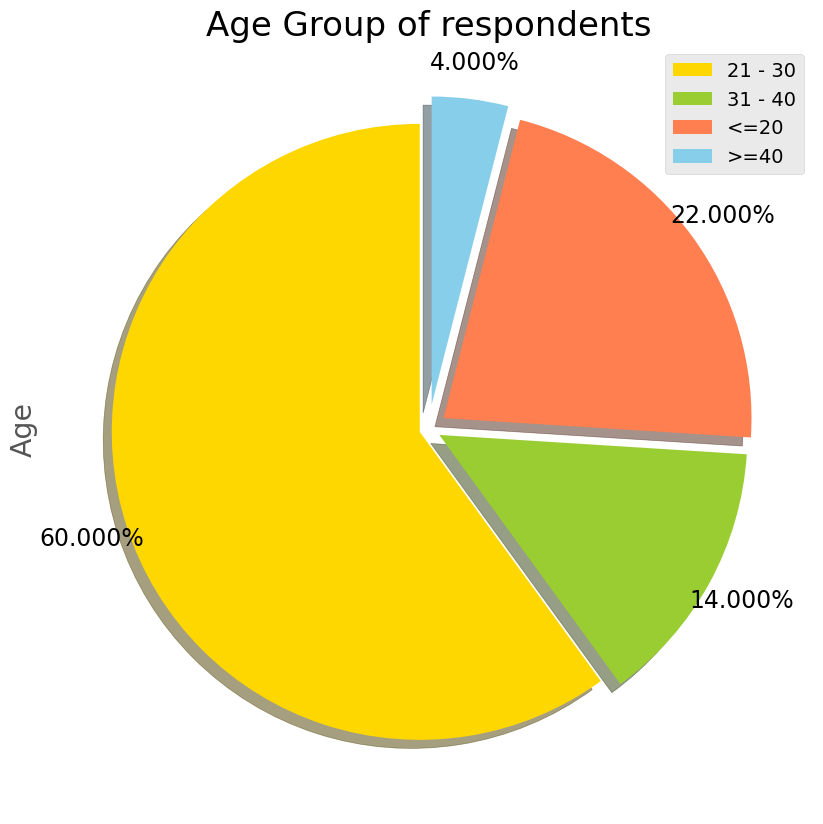

In [30]:
explode_list = [0.03, 0.04, 0.06, 0.08] # ratio for each continent with which to offset each wedge.
colors_list = ['gold', 'yellowgreen', 'coral', 'skyblue', 'lightgreen', 'pink']

mpl.rcParams['font.size'] = 17.0

dFast.groupby(['AgeGP']).count().plot(kind='pie',
                                      y='Age',
                                      fontsize = 17,
                                      figsize=(15,10),
                                      autopct='%1.3f%%',
                                      startangle=90,
                                      shadow=True,
                                      labels=None,                 # turn off labels on pie chart
                                      pctdistance=1.12,            # the ratio between the pie center and start of text label
                                      explode=explode_list,        # 'explode' lowest 3 continents
                                      colors=colors_list,
                                      title='Age Group of respondents'
                                     )
plt.legend(labels=df_grouped.index,
           bbox_to_anchor=(1.0,1.0),
           fontsize = 14)
plt.show()

alternatevely:

In [31]:
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
exps   = [0.05, 0.05, 0.02, 0.02]

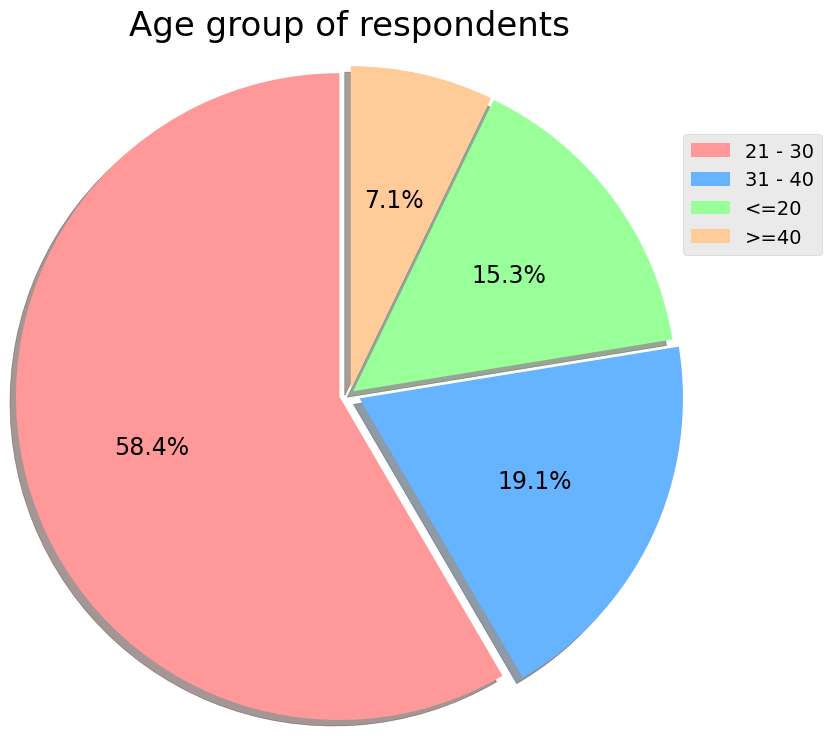

In [32]:
dFast.groupby(['AgeGP']).sum().plot(kind='pie', y='Age',
                                    autopct='%1.1f%%',
                                    radius=1.5,
                                    shadow=True,
                                    explode=exps,
                                    colors=colors,
                                    ylabel='',
                                    labeldistance=None,
                                    startangle = 90
                                   )
plt.legend(bbox_to_anchor=(1.1,1.0),
           fontsize = 14)
plt.title('Age group of respondents', y=1.15);

To see the gender in each age group:

In [33]:
df.columns

Index(['Age', 'Gender', 'Ocupation', 'Monthly income', 'Price', 'Quality',
       'Quantity', 'Availability', 'Taste', 'Flavours', 'Customer relation',
       'Customer services', 'Texture', 'Size', 'Overal satisfaction',
       'Consistency', 'Factor', 'Frowned', 'Popular', 'My favorite', 'Kind',
       'Preference', 'Recommend', 'AgeGP'],
      dtype='object')

using value_counts fun.

In [34]:
age_sex = df[['AgeGP', 'Gender']].value_counts()
age_sex = age_sex.to_frame()
age_sex

count
AgeGP   Gender       
21 - 30 Male       19
        Female     11
<=20    Male        6
31 - 40 Female      5
<=20    Female      5
31 - 40 Male        2
>=40    Female      1
        Male        1

alternatively, with groupby & size:

In [35]:
age_gender = df.groupby(['AgeGP', 'Gender']).size()
age_gender = age_gender.to_frame()
age_gender

0
AgeGP   Gender    
21 - 30 Female  11
        Male    19
31 - 40 Female   5
        Male     2
<=20    Female   5
        Male     6
>=40    Female   1
        Male     1

alternatively, with pivot table:

In [36]:
age_sex3 = pd.pivot_table(index = ['AgeGP', 'Gender'],
                          aggfunc=len,
                          #values = '',
                          values = 'Availability',
                          data = df,
                         margins = True)
age_sex3

Availability
AgeGP   Gender              
21 - 30 Female            11
        Male              19
31 - 40 Female             5
        Male               2
<=20    Female             5
        Male               6
>=40    Female             1
        Male               1
All                       50

In [37]:
age_gender = age_gender.rename(columns ={0: 'Count'})
age_gender = age_gender.reset_index()
age_gender

,AgeGP,Gender,Count
0,21 - 30,Female,11
1,21 - 30,Male,19
2,31 - 40,Female,5
3,31 - 40,Male,2
4,<=20,Female,5
5,<=20,Male,6
6,>=40,Female,1
7,>=40,Male,1


In [38]:
age_gender['%'] = (age_gender.iloc[:,2]/age_gender.iloc[:,2].sum())*100
age_gender

,AgeGP,Gender,Count,%
0,21 - 30,Female,11,22.0
1,21 - 30,Male,19,38.0
2,31 - 40,Female,5,10.0
3,31 - 40,Male,2,4.0
4,<=20,Female,5,10.0
5,<=20,Male,6,12.0
6,>=40,Female,1,2.0
7,>=40,Male,1,2.0


In [39]:
#plot_order = df.groupby('Age')['Sex'].sum().sort_values(ascending=False).index.values
plot_order = ['21 - 30',  '<=20', '31 - 40', '>40']

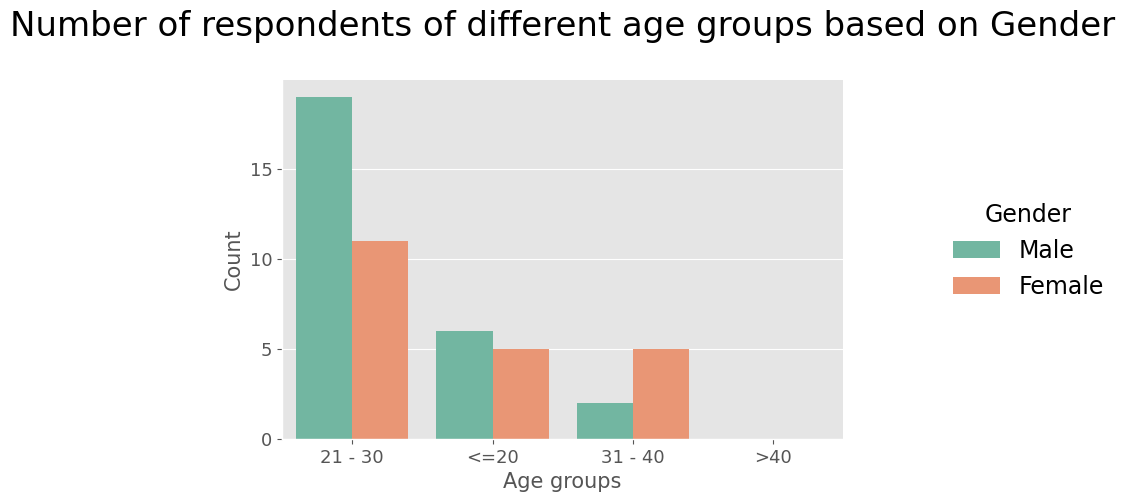

In [40]:
g = sns.catplot(x="AgeGP",
            kind="count",
            palette="Set2",
            hue = 'Gender',
            data=df,
            #index=['<=20','21-30','31-40', '41-50']
            #order=df.model.value_counts().index
                height=10,
                aspect=1.5,
                order = plot_order,
           )
g.fig.set_size_inches(7.2, 5)
g.fig.subplots_adjust(top=0.81, right=0.86)

ax = g.facet_axis(0, 0)

###for c in ax.containers:
###   labels = [f'{(v.get_height()):.0f}' for v in c]
###  ax.bar_label(c, labels=labels, label_type='edge', fontsize=12)

plt.xlabel('Age groups',fontsize=15)
plt.ylabel('Count',fontsize=15)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.title('Number of respondents of different age groups based on Gender', y =1.1)

plt.savefig('age_gender.png')

plt.show()

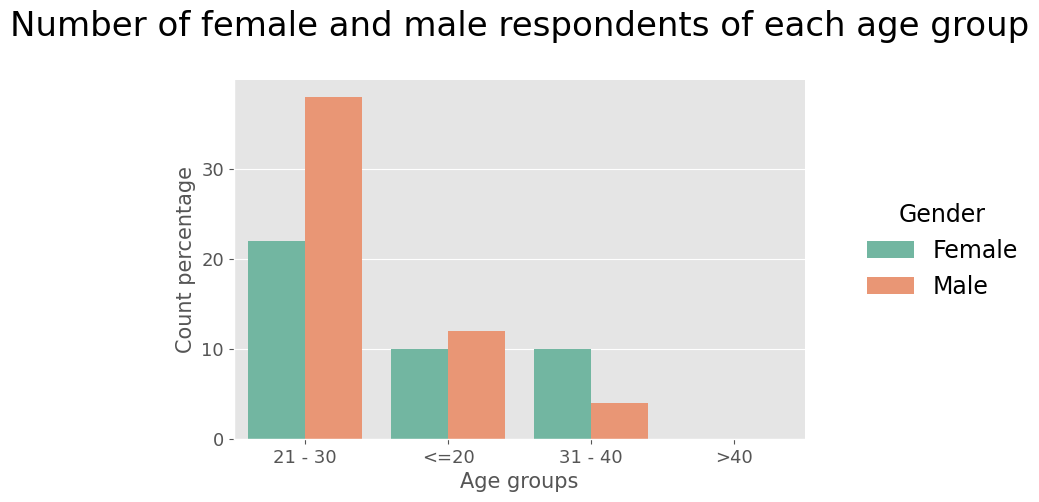

In [41]:
g = sns.catplot(x="AgeGP",  #Age	Sex	Count	%
                y = '%',
                palette="Set2",
                hue = 'Gender',
                data=age_gender,
                kind = 'bar',
                #index=['<=20','21-30','31-40', '41-50']
                #order=df.model.value_counts().index
                height=10,
                aspect=1.5,
                order = plot_order,
               )
g.fig.set_size_inches(7.2, 5)
g.fig.subplots_adjust(top=0.81, right=0.86)

ax = g.facet_axis(0, 0)

###for c in ax.containers:
###    labels = [f'{(v.get_height()):.0f}' for v in c]
###    ax.bar_label(c, labels=labels, label_type='edge', fontsize=12)

plt.xlabel('Age groups',fontsize=15)
plt.ylabel('Count percentage',fontsize=15)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.title('Number of female and male respondents of each age group', y =1.1)
plt.savefig('age_sex.png')

plt.savefig('age_group2.png')
plt.show()

In [42]:
age_gender

,AgeGP,Gender,Count,%
0,21 - 30,Female,11,22.0
1,21 - 30,Male,19,38.0
2,31 - 40,Female,5,10.0
3,31 - 40,Male,2,4.0
4,<=20,Female,5,10.0
5,<=20,Male,6,12.0
6,>=40,Female,1,2.0
7,>=40,Male,1,2.0


In [43]:
fig = px.sunburst(age_gender,
                  path=['AgeGP','Gender','Count',],
                  values='Count',
                  color='AgeGP',
                  #color_discrete_map={'(?)':'black', 'Sex':'Orange', 'Count':'darkblue'},
                  title='Number of respondents of different age groups'
                 )

plt.savefig('age_group3.png')
fig.show();

<Figure size 1500x700 with 0 Axes>

### Satisfaction on PRICE of different age groups and Gender

In [44]:
price_pivt_pas = pd.pivot_table(data = df,
                           index = ['Price','AgeGP','Gender'],
                           #values = 'Price',
                           aggfunc = 'size',
                           )
price_pivt_pas = price_pivt_pas.to_frame()
price_pivt_pas = price_pivt_pas.reset_index()
price_pivt_pas = price_pivt_pas.rename(columns ={0: 'Size'}
                 )
price_pivt_pas['%'] = (price_pivt_pas.iloc[:,3]/price_pivt_pas.loc[:,'Size'].sum(axis=0))*100
price_pivt_pas

,Price,AgeGP,Gender,Size,%
0,1.0,21 - 30,Female,1,2.0
1,2.0,21 - 30,Male,2,4.0
2,2.0,<=20,Male,3,6.0
3,3.0,21 - 30,Female,3,6.0
4,3.0,21 - 30,Male,8,16.0
5,3.0,31 - 40,Female,3,6.0
6,3.0,31 - 40,Male,1,2.0
7,3.0,<=20,Female,4,8.0
8,3.0,<=20,Male,1,2.0
9,4.0,21 - 30,Female,4,8.0


In [45]:
fig = px.sunburst(price_pivt_pas,
                  path=[  'Gender', 'AgeGP','Price'],
                  values='%',
                  color='AgeGP',
                  color_discrete_map={'(?)':'black', 'Lunch':'gold', 'Dinner':'darkblue'},
                  title='Satisfaction on PRICE of different age groups and Gender'
                 )
fig.update_traces(textinfo='label+percent entry')
plt.savefig('sample_data/age_group3.png')
fig.show()
#1

<Figure size 1500x700 with 0 Axes>

In [46]:
price_pivt_pas

,Price,AgeGP,Gender,Size,%
0,1.0,21 - 30,Female,1,2.0
1,2.0,21 - 30,Male,2,4.0
2,2.0,<=20,Male,3,6.0
3,3.0,21 - 30,Female,3,6.0
4,3.0,21 - 30,Male,8,16.0
5,3.0,31 - 40,Female,3,6.0
6,3.0,31 - 40,Male,1,2.0
7,3.0,<=20,Female,4,8.0
8,3.0,<=20,Male,1,2.0
9,4.0,21 - 30,Female,4,8.0


In [47]:
fig = px.sunburst(price_pivt_pas,
                  path=['Price', 'AgeGP','Gender', ],
                  values='%',
                  color='AgeGP',
                  color_discrete_map={'(?)':'black', 'Lunch':'gold', 'Dinner':'darkblue'},
                  title='Satisfaction on PRICE of different age groups and sex'
                 )
fig.update_traces(textinfo='label+percent entry')
plt.savefig('sample_data/age_group3.png')
fig.show()

<Figure size 1500x700 with 0 Axes>

In [48]:
fig = px.sunburst(price_pivt_pas,
                  path=['Price', 'Gender', 'AgeGP',],
                  values='%',
                  color='AgeGP',
                  title='Satisfaction on PRICE of different age groups and sex'
                 )

fig.update_traces(textinfo='label+percent entry')
plt.savefig('sample_data/age_group3.png')
fig.show()

<Figure size 1500x700 with 0 Axes>

In [49]:
age_gender

,AgeGP,Gender,Count,%
0,21 - 30,Female,11,22.0
1,21 - 30,Male,19,38.0
2,31 - 40,Female,5,10.0
3,31 - 40,Male,2,4.0
4,<=20,Female,5,10.0
5,<=20,Male,6,12.0
6,>=40,Female,1,2.0
7,>=40,Male,1,2.0


In [50]:
fig = px.bar(age_gender,
             y="AgeGP",
             x="Count",
             color="Gender",
             orientation="h",
             hover_name="AgeGP",
             color_discrete_sequence=["lightslategrey", "lightcyan"],
             category_orders={"AgeGP": ["21 - 30", "31 - 40", "<=20", ">=40"]},
             title="Explicit color mapping"
            )

fig.show()

<!--NAVIGATION-->
< [Previous](https://github.com/Egade/ClassNotes)
| [Toc](https://github.com/Egade/ClassNotes)
| [Next](https://github.com/Egade/ClassNotes) >